In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import os
import pathlib
import seaborn as sns


from sklearn.model_selection import GroupKFold
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, root_mean_squared_error, r2_score


from seaborn import set_style
set_style("whitegrid")

In [22]:
# Source - https://stackoverflow.com/a/50051542
# Posted by Aaron Brock, modified by community. See post 'Timeline' for change history
# Retrieved 2026-02-26, License - CC BY-SA 3.0

def to_csv(df, path):
    # Prepend dtypes to the top of df (from https://stackoverflow.com/a/43408736/7607701)
    df.loc[-1] = df.dtypes
    df.index = df.index + 1
    df.sort_index(inplace=True)
    # Then save it to a csv
    df.to_csv(path, index=False)

def read_csv(path):
    # Read types first line of csv
    dtypes = {key:value for (key,value) in pd.read_csv(path,    
              nrows=1).iloc[0].to_dict().items() if 'date' not in value}

    parse_dates = [key for (key,value) in pd.read_csv(path, 
                   nrows=1).iloc[0].to_dict().items() if 'date' in value]
    # Read the rest of the lines with the types from above
    return pd.read_csv(path, dtype=dtypes, parse_dates=parse_dates, skiprows=[1])

In [23]:
#Read in the processed test data
loc = '../data/schedule_data/train_test_split_data/by_weekday/'

cols = ['date','Time of Day (morning: 0-late evening: 4)*','Weekday=0/Sat=1/Sun=2','EB/WB','bunch','gap','total delay']

csv_file_names = [loc+file for file in os.listdir(loc) if file.endswith('train.csv')]
list_of_dataframes = [read_csv(file)[cols] 
    for file in csv_file_names]
train_df = pd.concat(list_of_dataframes, ignore_index=True)

train_df = train_df.rename(columns={
    'Time of Day (morning: 0-late evening: 4)*': 'time_period',
    'Weekday=0/Sat=1/Sun=2': 'weekday',
    'EB/WB': 'direction',
    'total delay': 'total_delay'
})

# combine EB/WB rows into one row per date/time_period/day

train_df = (
    train_df
    .groupby(['date', 'time_period', 'weekday'], as_index=False)[['bunch', 'gap', 'total_delay']]
    .sum()
)

In [24]:
print(f"Correlations: \n{train_df[['time_period','bunch','gap','total_delay']].corr()}\n\n")

daily_stat = (
    train_df
    .groupby('date')[['bunch','gap','total_delay']]
    .sum()
    .reset_index()
)


print(f"Daily Total Correlations:\n{daily_stat[['bunch','gap','total_delay']].corr()}\n\n")

print(f"Log Log Correlations: \n{np.log1p(train_df[['bunch','gap','total_delay']]).corr()}\n\n")

print(f"Daily Log Log Correlations: \n{np.log1p(daily_stat[['bunch','gap','total_delay']]).corr()}\n\n")

# Comparing the correlations for each individual observation shows that bunching 
# and gapping appear to have a fairly strong positive correlation.
# The number of gapping incidents has a slightly stronger correlation with 
# total delay than bunching.
# Strangely enough, comparing with total counts for each day, 
# the correlation between gap and total delay increases, while the correlation 
# between bunching and total delay decreases.
# This could indicate that relationship between bunching and total delay time is more influenced 
# by the effects of the time period than gapping is.


Correlations: 
             time_period     bunch       gap  total_delay
time_period     1.000000  0.316084 -0.058189     0.086622
bunch           0.316084  1.000000  0.482014     0.540608
gap            -0.058189  0.482014  1.000000     0.671429
total_delay     0.086622  0.540608  0.671429     1.000000


Daily Total Correlations:
                bunch       gap  total_delay
bunch        1.000000  0.399236     0.452380
gap          0.399236  1.000000     0.789631
total_delay  0.452380  0.789631     1.000000


Log Log Correlations: 
                bunch       gap  total_delay
bunch        1.000000  0.528371     0.656366
gap          0.528371  1.000000     0.647380
total_delay  0.656366  0.647380     1.000000


Daily Log Log Correlations: 
                bunch       gap  total_delay
bunch        1.000000  0.451376     0.538176
gap          0.451376  1.000000     0.795312
total_delay  0.538176  0.795312     1.000000




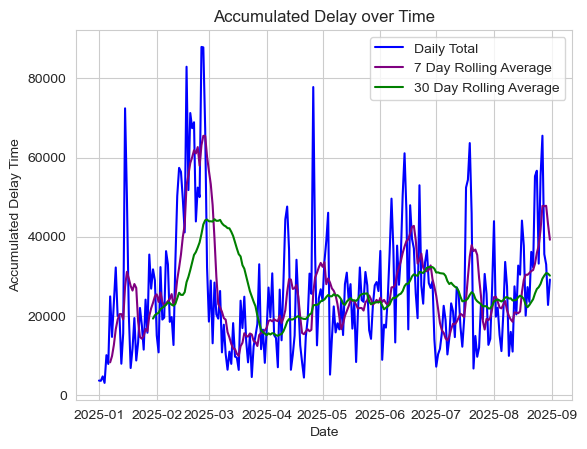

In [25]:
# Let's look at how the accumulated delay time (daily and monthly) varies over time 


#plt.scatter(
#    train_df['date'], 
#    train_df['total_delay'], 
#    alpha=0.1, 
#    s=5
#)

# daily total
daily_tot = (
    train_df
    .groupby('date')['total_delay']
    .sum()
    .reset_index()
)

plt.plot(
    daily_tot['date'],
    daily_tot['total_delay'],
    color='blue',
    label="Daily Total"
)

# 7 day rolling average
daily_tot['rolling_week'] = daily_tot['total_delay'].rolling(7).mean()

plt.plot(
    daily_tot['date'],
    daily_tot['rolling_week'],
    color='purple',
    label="7 Day Rolling Average"
)
# 30 day rolling average
daily_tot['rolling_month'] = daily_tot['total_delay'].rolling(30).mean()

plt.plot(
    daily_tot['date'],
    daily_tot['rolling_month'],
    color='green',
    label="30 Day Rolling Average"
)


plt.xlabel("Date")
plt.ylabel("Accumulated Delay Time")
plt.title("Accumulated Delay over Time")
plt.legend()
plt.show()

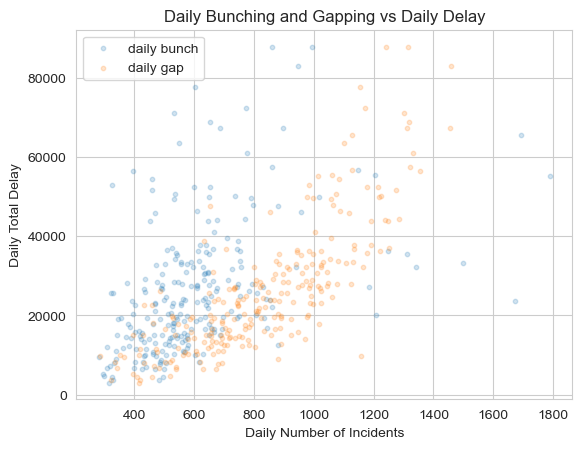

In [26]:
# Next we look at how the number of bunching and gapping incidents vary over time

plt.scatter(
    daily_stat['bunch'], 
    daily_stat['total_delay'], 
    alpha=0.2, 
    s=10,
    label = "daily bunch"
)
plt.scatter(
    daily_stat['gap'], 
    daily_stat['total_delay'], 
    alpha=0.2, 
    s=10,
    label = "daily gap"
)
plt.xlabel("Daily Number of Incidents")
plt.ylabel("Daily Total Delay")
plt.title("Daily Bunching and Gapping vs Daily Delay")
plt.legend()
plt.show()


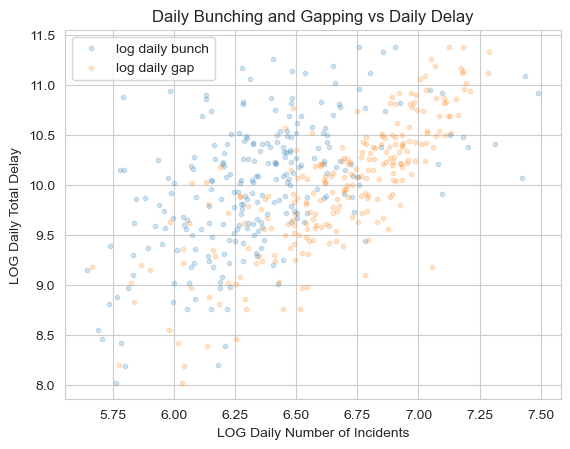

In [27]:
# Next we look at how the number of bunching and gapping incidents vary over time


plt.scatter(
    np.log1p(daily_stat['bunch']), 
    np.log1p(daily_stat['total_delay']), 
    alpha=0.2, 
    s=10,
    label = "log daily bunch"
)
plt.scatter(
    np.log1p(daily_stat['gap']), 
    np.log1p(daily_stat['total_delay']), 
    alpha=0.2, 
    s=10,
    label = "log daily gap"
)
plt.xlabel("LOG Daily Number of Incidents")
plt.ylabel("LOG Daily Total Delay")
plt.title("Daily Bunching and Gapping vs Daily Delay")
plt.legend()
plt.show()


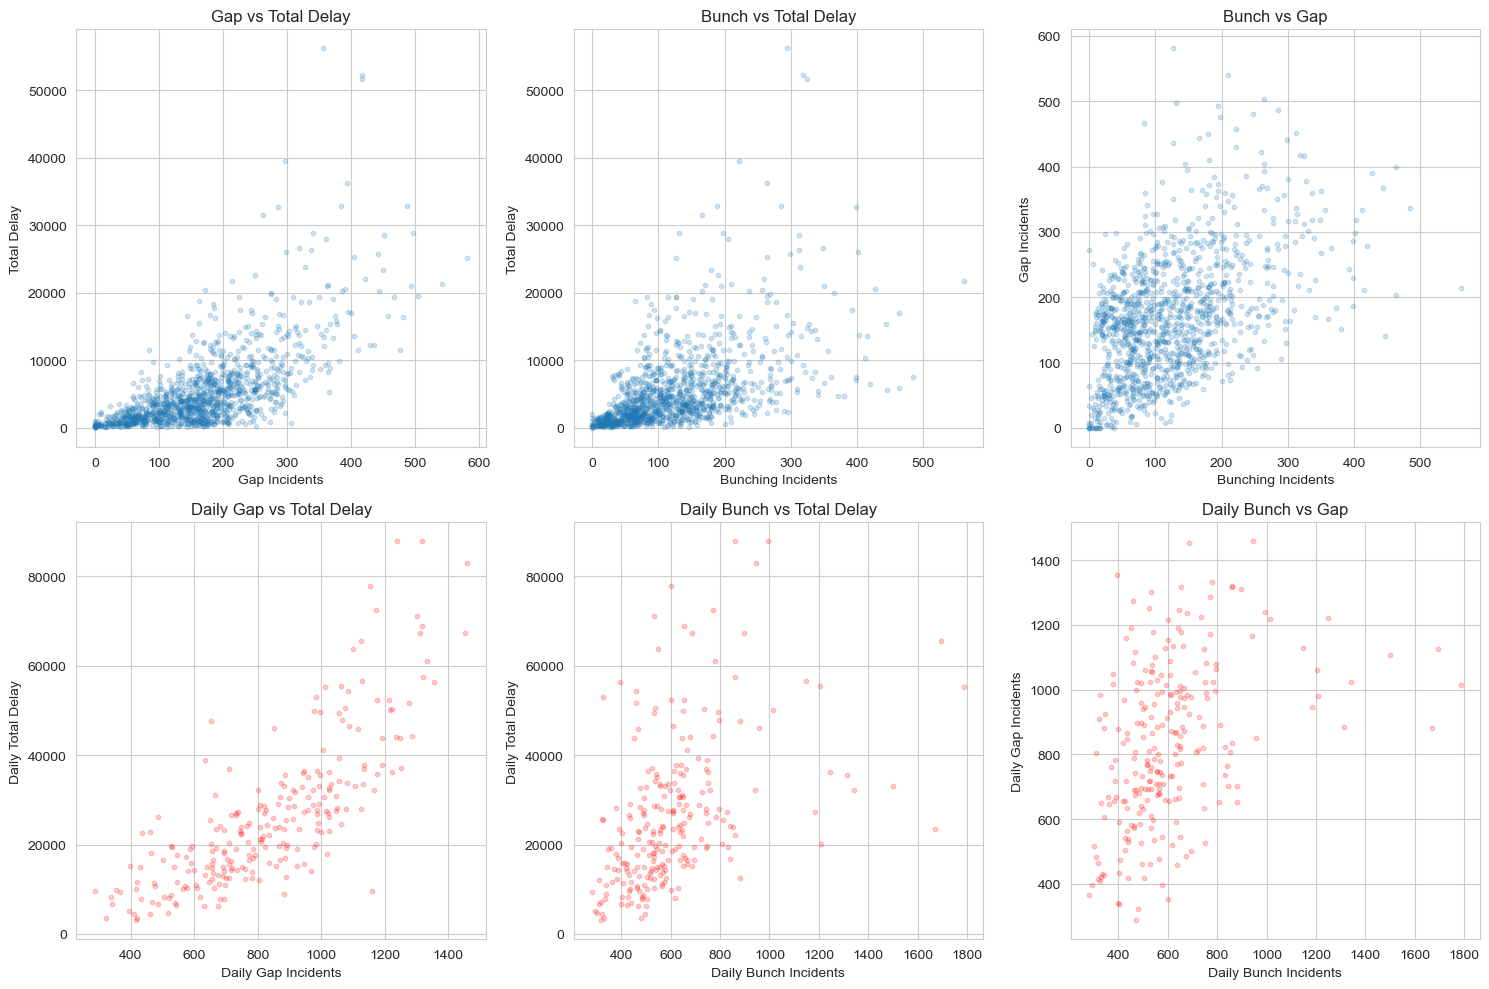

In [28]:
# Lets compare Gap, Bunch, and Total Delay for each observation, and for the daily totals

daily_stat = (
    train_df
    .groupby('date')[['bunch','gap','total_delay']]
    .sum()
    .reset_index()
)

fig, axes = plt.subplots(2, 3, figsize=(15,10))

# -----------------------------
# Individual observations
# -----------------------------

# gap vs delay
axes[0,0].scatter(
    train_df['gap'],
    train_df['total_delay'],
    alpha=0.2,
    s=10
)
axes[0,0].set_xlabel("Gap Incidents")
axes[0,0].set_ylabel("Total Delay")
axes[0,0].set_title("Gap vs Total Delay")

# bunch vs delay
axes[0,1].scatter(
    train_df['bunch'],
    train_df['total_delay'],
    alpha=0.2,
    s=10
)
axes[0,1].set_xlabel("Bunching Incidents")
axes[0,1].set_ylabel("Total Delay")
axes[0,1].set_title("Bunch vs Total Delay")

# bunch vs gap
axes[0,2].scatter(
    train_df['bunch'],
    train_df['gap'],
    alpha=0.2,
    s=10
)
axes[0,2].set_xlabel("Bunching Incidents")
axes[0,2].set_ylabel("Gap Incidents")
axes[0,2].set_title("Bunch vs Gap")

# -----------------------------
# Daily totals
# -----------------------------

# gap vs delay
axes[1,0].scatter(
    daily_stat['gap'],
    daily_stat['total_delay'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[1,0].set_xlabel("Daily Gap Incidents")
axes[1,0].set_ylabel("Daily Total Delay")
axes[1,0].set_title("Daily Gap vs Total Delay")

# bunch vs delay
axes[1,1].scatter(
    daily_stat['bunch'],
    daily_stat['total_delay'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[1,1].set_xlabel("Daily Bunch Incidents")
axes[1,1].set_ylabel("Daily Total Delay")
axes[1,1].set_title("Daily Bunch vs Total Delay")

# bunch vs gap
axes[1,2].scatter(
    daily_stat['bunch'],
    daily_stat['gap'],
    alpha=0.2,
    s=10,
    color='red'
)
axes[1,2].set_xlabel("Daily Bunch Incidents")
axes[1,2].set_ylabel("Daily Gap Incidents")
axes[1,2].set_title("Daily Bunch vs Gap")

plt.tight_layout()
plt.show()

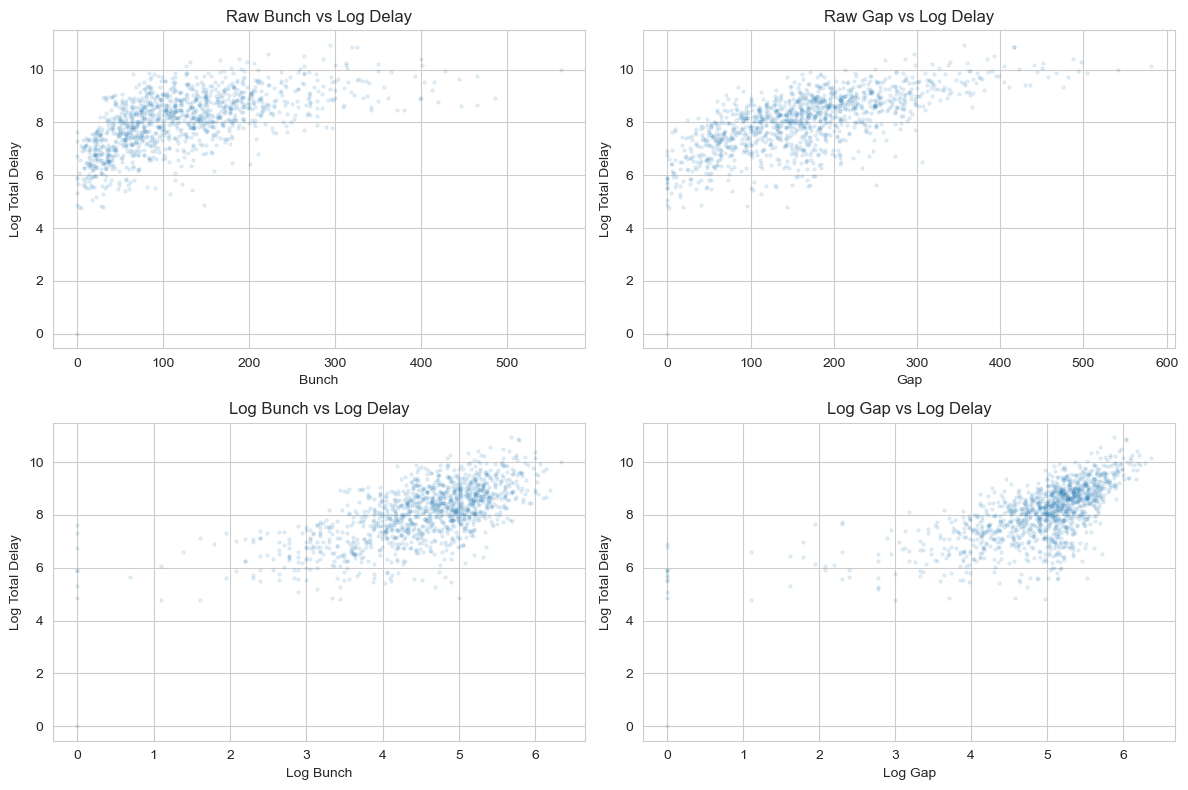

In [29]:
# Repeat the analysis using a log transformation of delay
# The relationship between delay and bunching/gapping appears roughly linear, but the variance increases as the number of bunching or gapping events grows.
# So now we will also consider a log–log transformation and see if that tightens things up.


# Create transformed variables
train_df['log_total_delay'] = np.log1p(train_df['total_delay'])
train_df['log_bunch'] = np.log1p(train_df['bunch'])
train_df['log_gap'] = np.log1p(train_df['gap'])


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# -----------------------------
# Individual observations with Raw Bunch and Gap and Log Total delay
# -----------------------------

axes[0,0].scatter(
    train_df['bunch'],
    train_df['log_total_delay'],
    alpha=0.1,
    s=5
)
axes[0,0].set_title("Raw Bunch vs Log Delay")
axes[0,0].set_xlabel("Bunch")
axes[0,0].set_ylabel("Log Total Delay")

axes[0,1].scatter(
    train_df['gap'],
    train_df['log_total_delay'],
    alpha=0.1,
    s=5
)
axes[0,1].set_title("Raw Gap vs Log Delay")
axes[0,1].set_xlabel("Gap")
axes[0,1].set_ylabel("Log Total Delay")

# -----------------------------
# Individual observations with Log Bunch and Gap and Log Total delay
# -----------------------------


axes[1,0].scatter(
    train_df['log_bunch'],
    train_df['log_total_delay'],
    alpha=0.1,
    s=5
)
axes[1,0].set_title("Log Bunch vs Log Delay")
axes[1,0].set_xlabel("Log Bunch")
axes[1,0].set_ylabel("Log Total Delay")

axes[1,1].scatter(
    train_df['log_gap'],
    train_df['log_total_delay'],
    alpha=0.1,
    s=5
)
axes[1,1].set_title("Log Gap vs Log Delay")
axes[1,1].set_xlabel("Log Gap")
axes[1,1].set_ylabel("Log Total Delay")

plt.tight_layout()
plt.show()

In [30]:
# Based on our observations so far, we will build a model using log transformed features: 
# 1. log(total_delay) ~ log(bunch) + time_period + weekday
# For comparison, we will look at the following additional models:
# 2. log(total_delay) ~ bunch + time_period + weekday
# 3. total_delay ~ bunch + time_period + weekday
models = {
    "baseline": {
        "target": "total_delay",
        "features": ["time_period", "weekday"]
    },

    "log_delay_log_bunch": {
        "target": "log_total_delay",
        "features": ["log_bunch", "time_period", "weekday"]
    },
    

    "log_delay_raw_bunch": {
        "target": "log_total_delay",
        "features": ["bunch", "time_period", "weekday"]
    },
    

    "raw_delay_raw_bunch": {
        "target": "total_delay",
        "features": ["bunch", "time_period", "weekday"]
    },


# In addition, we will repeat this analysis with with models that also include gap as a feature. 

    
    "log_delay_log_bunch_log_gap": {
        "target": "log_total_delay",
        "features": ["log_bunch", "log_gap", "time_period", "weekday"]
    },
    
    
    "log_delay_raw_bunch_raw_gap": {
        "target": "log_total_delay",
        "features": ["bunch", "gap", "time_period", "weekday"]
    },
    
    
    "raw_delay_raw_bunch_raw_gap": {
        "target": "total_delay",
        "features": ["bunch", "gap", "time_period", "weekday"]
    }
}

In [31]:
# Now we will split the training data into folds for cross validation. 

#The splits are based on date so that all time periods from the same day remain in the same fold, preventing data leakage.

def date_splits(df, n_folds=5, date_col="date"):
    sorted_df = df.copy()
    sorted_df[date_col] = pd.to_datetime(sorted_df[date_col])
    sorted_df = sorted_df.sort_values(date_col).reset_index(drop=True)

    unique_dates = np.sort(sorted_df[date_col].unique())
    date_blocks = np.array_split(unique_dates, n_folds + 1)
    splits = []

    for i in range(1, n_folds + 1):
        train_cv_dates = np.concatenate(date_blocks[:i])
        holdout_cv_dates = date_blocks[i]
        
        train_idx = sorted_df.index[sorted_df[date_col].isin(train_cv_dates)].to_numpy()
        holdout_idx = sorted_df.index[sorted_df[date_col].isin(holdout_cv_dates)].to_numpy()

        splits.append((train_idx, holdout_idx))

    return splits, sorted_df

bunch_cv_splits, bunch_cv_train_df = date_splits(train_df, n_folds=5, date_col="date")


In [39]:
bunch_cv_results = []

for model_name, cols in models.items():
    fold_maes = []
    fold_rmses = []
    fold_r2s = []

    for fold, (train_idx, holdout_idx) in enumerate(bunch_cv_splits, start=1):
        fold_train_df = bunch_cv_train_df.iloc[train_idx].copy()
        fold_holdout_df = bunch_cv_train_df.iloc[holdout_idx].copy()

        X_train = fold_train_df[cols["features"]].copy()
        X_holdout = fold_holdout_df[cols["features"]].copy()

        y_train = fold_train_df[cols["target"]].copy()
        y_holdout = fold_holdout_df[cols["target"]].copy()

        # One-hot encode categorical predictors
        X_train = pd.get_dummies(X_train, drop_first=True)
        X_holdout = pd.get_dummies(X_holdout, drop_first=True)

        # Make sure holdout columns match training columns
        X_holdout = X_holdout.reindex(columns=X_train.columns, fill_value=0)

        model = LinearRegression()
        model.fit(X_train, y_train)
        y_pred = model.predict(X_holdout)

        mae = mean_absolute_error(y_holdout, y_pred)
        rmse = np.sqrt(mean_squared_error(y_holdout, y_pred))
        r2 = r2_score(y_holdout, y_pred)

        fold_maes.append(mae)
        fold_rmses.append(rmse)
        fold_r2s.append(r2)


        print(
            f"{model_name}, Fold {fold}: "
            f"train_days={fold_train_df['date'].nunique()}, "
            f"holdout_days={fold_holdout_df['date'].nunique()}, "
            f"MAE={mae:.2f}, RMSE={rmse:.2f}, R^2={r2:.2f}"
        )

    coef = pd.Series(model.coef_, index=X_train.columns)
    print(f"{model}, coefficients: \n {coef.sort_values()}")

    bunch_cv_results.append({
        "model": model_name,
        "mean_cv_mae": np.mean(fold_maes),
         "sd_cv_mae": np.std(fold_maes),
        "mean_cv_rmse": np.mean(fold_rmses),
        "sd_cv_rmse": np.std(fold_rmses),
        "mean_cv_r2": np.mean(fold_r2s),
        "sd_cv_r2": np.std(fold_r2s)
    })


baseline, Fold 1: train_days=41, holdout_days=41, MAE=5085.02, RMSE=8757.70, R^2=-0.10
baseline, Fold 2: train_days=82, holdout_days=41, MAE=3824.47, RMSE=5364.01, R^2=-0.13
baseline, Fold 3: train_days=123, holdout_days=40, MAE=3128.82, RMSE=4376.99, R^2=-0.06
baseline, Fold 4: train_days=163, holdout_days=40, MAE=3912.20, RMSE=5560.48, R^2=-0.02
baseline, Fold 5: train_days=203, holdout_days=40, MAE=3196.88, RMSE=4325.64, R^2=0.04
LinearRegression(), coefficients: 
 time_period    157.072964
weekday        177.042268
dtype: float64
log_delay_log_bunch, Fold 1: train_days=41, holdout_days=41, MAE=0.85, RMSE=1.06, R^2=0.22
log_delay_log_bunch, Fold 2: train_days=82, holdout_days=41, MAE=0.65, RMSE=0.82, R^2=0.41
log_delay_log_bunch, Fold 3: train_days=123, holdout_days=40, MAE=0.52, RMSE=0.65, R^2=0.42
log_delay_log_bunch, Fold 4: train_days=163, holdout_days=40, MAE=0.69, RMSE=0.89, R^2=0.43
log_delay_log_bunch, Fold 5: train_days=203, holdout_days=40, MAE=0.59, RMSE=0.74, R^2=0.38
Li

In [40]:
bunch_cv_results_df = pd.DataFrame(bunch_cv_results)
print("\nCross-validation summary:")
print(bunch_cv_results_df)


Cross-validation summary:
                         model  mean_cv_mae   sd_cv_mae  mean_cv_rmse  \
0                     baseline  3829.479016  703.470970   5676.964414   
1          log_delay_log_bunch     0.659420    0.111436      0.834055   
2          log_delay_raw_bunch     0.720399    0.095231      0.908617   
3          raw_delay_raw_bunch  3330.992337  589.887935   4980.628144   
4  log_delay_log_bunch_log_gap     0.559177    0.096708      0.705202   
5  log_delay_raw_bunch_raw_gap     0.561527    0.008819      0.715623   
6  raw_delay_raw_bunch_raw_gap  2825.286159  400.659161   4091.811938   

    sd_cv_rmse  mean_cv_r2  sd_cv_r2  
0  1619.780542   -0.054030  0.058797  
1     0.139495    0.372484  0.078808  
2     0.126861    0.253298  0.057602  
3  1282.251541    0.162452  0.199694  
4     0.124361    0.548899  0.079363  
5     0.039830    0.521584  0.089874  
6  1151.943948    0.440468  0.117987  
